<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 3</h3>
    <h3>Ejercicio 1</h3>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistentes: Sebastián Calcagno y Braian Drago<p>
</div>

<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Datos de Turismo - Pruebas de raiz unitaria y Modelos ARMA/SARIMA</title>
</head>
<body>
    <p>
        Los datos se obtienen de la siguiente fuente:
        <a href="https://datos.gob.ar/dataset/turismo-encuesta-ocupacion-hotelera-parahotelera-eoh/archivo/turismo_d1624c27-4b0d-4b73-b0f8-e7db5c56386f" target="_blank">
            https://datos.gob.ar/dataset/ turismo-encuesta-ocupacion-hotelera-parahotelera-eoh/archivo/turismo_d1624c27-4b0d-4b73-b0f8-e7db5c56386f
        </a>. <br>
        Es la cantidad de viajeros alojados en establecimientos hoteleros y parahoteleros según residencia en formato de series de tiempo.
    </p>
</body>
</html>


Aca analizamos una serie mensual de viajeros residentes alojados en hoteles de Argentina y construimos un buen modelo de pronóstico.

BAsicamente como siempre primero preparamos y graficamos la serie, limitando los datos hasta enero de 2020 y separando 80 % para entrenamiento y 20 % para prueba.
Analiza estacionariedad y estacionalidad con descomposicion FAC/FACP y pruebas ADF, KPSS y Phillips-Perron.
Aplicamos diferencia regular y estacional de 12 meses para estabilizar la serie.
Ajustamos y compara modelos ARMA y SARIMA revisamos sus residuos con Ljung-Box y evaluamos los pronosticos con MAE MsE RMSE y MAPE.
Finalmente combina dos modelos SARIMA mediante un ensemble promedio

Recumen gral primero se comprueba si la serie es estacionaria desp se eliminan la tendencia y la estacionalidad mediante diferencias, se ajustan diferentes modelos y se elige el que presenta mejores pronósticos y residuos similares a ruido blanco

# Carga de librerias y preparacion de las bases a trabajar

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 25.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import statsmodels.tsa.stattools as tsa
from statsmodels.tsa.arima_model import ARIMA
from matplotlib import pyplot

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox, acorr_breusch_godfrey
from scipy.stats import jarque_bera, shapiro, boxcox, probplot
from datetime import timedelta

In [ ]:
import statsmodels.api as sm

In [ ]:
# Esta funcion descompone la serie en sus partes para ver estacionalidad, tendencia, residuos. por defecto hace aditivo
def componentes(timeserie):
  decomposition = seasonal_decompose(timeserie, period=12)
  fig = plt.figure()
  fig = decomposition.plot()
  fig.set_size_inches(15, 8)

In [ ]:
url='https://raw.githubusercontent.com/sebcalcagno/AnalisisSeriesTemporales/main/base_clase4.csv'
serie_inicial = pd.read_csv(url)

In [ ]:
serie_inicial.head()

,indice_tiempo,origen_viajeros,viajeros,observaciones
0,2007-01-01,Residentes,1679499,NaN
1,2007-01-01,No residentes,464201,NaN
2,2007-02-01,Residentes,1493372,NaN
3,2007-02-01,No residentes,479876,NaN
4,2007-03-01,Residentes,1285612,NaN


In [ ]:
serie_inicial.indice_tiempo = pd.to_datetime(serie_inicial.indice_tiempo)#, dayfirst = True)

In [ ]:
serie_inicial.dtypes

,0
indice_tiempo,datetime64[ns]
origen_viajeros,object
viajeros,int64
observaciones,object


In [ ]:
serie_inicial.set_index("indice_tiempo", inplace=True)

In [ ]:
serie_inicial.head()

,origen_viajeros,viajeros,observaciones
indice_tiempo,,,
2007-01-01,Residentes,1679499,NaN
2007-01-01,No residentes,464201,NaN
2007-02-01,Residentes,1493372,NaN
2007-02-01,No residentes,479876,NaN
2007-03-01,Residentes,1285612,NaN


In [ ]:

print(serie_inicial.index)

print(serie_inicial)

DatetimeIndex(['2007-01-01', '2007-01-01', '2007-02-01', '2007-02-01',
               '2007-03-01', '2007-03-01', '2007-04-01', '2007-04-01',
               '2007-05-01', '2007-05-01',
               ...
               '2021-12-01', '2021-12-01', '2022-01-01', '2022-01-01',
               '2022-02-01', '2022-02-01', '2022-03-01', '2022-03-01',
               '2022-04-01', '2022-04-01'],
              dtype='datetime64[ns]', name='indice_tiempo', length=368, freq=None)
              origen_viajeros  viajeros    observaciones
indice_tiempo                                           
2007-01-01         Residentes   1679499              NaN
2007-01-01      No residentes    464201              NaN
2007-02-01         Residentes   1493372              NaN
2007-02-01      No residentes    479876              NaN
2007-03-01         Residentes   1285612              NaN
...                       ...       ...              ...
2022-02-01      No residentes    115315  Dato provisorio
2022-03-01    

In [ ]:
# Removemos la fila de observaciones ya que no aporta informacion relevante. Y filtramos info
serie_inicial = serie_inicial.drop(['observaciones'],axis=1)


serie_residentes = serie_inicial[serie_inicial["origen_viajeros"]=="Residentes"].drop("origen_viajeros",axis=1)
serie_no_residentes = serie_inicial[serie_inicial["origen_viajeros"]=="No residentes"].drop("origen_viajeros",axis=1)

In [ ]:
serie_residentes.head()

,viajeros
indice_tiempo,
2007-01-01,1679499
2007-02-01,1493372
2007-03-01,1285612
2007-04-01,1184937
2007-05-01,1017821


In [ ]:
print(type(serie_residentes))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
serie_residentes = serie_residentes.iloc[:,0]
print(type(serie_residentes))

serie_residentes = serie_residentes.asfreq(pd.infer_freq(serie_residentes.index))
print(serie_residentes.index) # Corroboramos que la frecuencia sea mensual -> freq='MS'

serie_residentes = pd.Series(serie_residentes[serie_residentes.index <= '2020-01-01'])

<class 'pandas.core.series.Series'>
DatetimeIndex(['2007-01-01', '2007-02-01', '2007-03-01', '2007-04-01',
               '2007-05-01', '2007-06-01', '2007-07-01', '2007-08-01',
               '2007-09-01', '2007-10-01',
               ...
               '2021-07-01', '2021-08-01', '2021-09-01', '2021-10-01',
               '2021-11-01', '2021-12-01', '2022-01-01', '2022-02-01',
               '2022-03-01', '2022-04-01'],
              dtype='datetime64[ns]', name='indice_tiempo', length=184, freq='MS')


In [ ]:
# Funcion para graficar
def graficar(serie, titulo="", xlabel="Año", ylabel="Pasajeros"):
    fig_x = plt.figure(figsize=(12,3), dpi=100)
    axes_x = fig_x.add_axes([0.0, 0.0, 1, 1])
    serie.plot()
    axes_x.set_xlabel(xlabel)
    axes_x.set_ylabel(ylabel)
    axes_x.set_title(titulo)
    axes_x.legend(loc=0)
    axes_x.grid(True, color='0.6', dashes=(5,2,1,2))

In [ ]:
# Funcion para dibujar juntos FAS: autocovarianzas; FAC y FACP, autocorrelacion y autocorrelacion parcial
def autocov_autocorr(serie_r, nrol=75):
    fig, axes = plt.subplots(3, 1, figsize=(18, 10))

    plot_acf(serie_r, lags=nrol, ax=axes[0], color='blue', vlines_kwargs={"colors": 'blue'})
    axes[0].set_title('ACF (Autocorrelación)', fontsize=14)

    plot_pacf(serie_r, lags=nrol, ax=axes[1], color='green', vlines_kwargs={"colors": 'green'}, method='ywm')
    axes[1].set_title('PACF (Autocorrelación Parcial)', fontsize=14)

    axes[2].plot(tsa.acovf(serie_r, fft=False, nlag=nrol), color='red', label='AutoCov')
    axes[2].set_title('Autocovarianza', fontsize=14)
    axes[2].set_xlabel('Lag')

    plt.tight_layout()
    plt.show()

In [ ]:
serie_residentes.head()

,viajeros
indice_tiempo,
2007-01-01,1679499
2007-02-01,1493372
2007-03-01,1285612
2007-04-01,1184937
2007-05-01,1017821


In [ ]:
print(serie_residentes.isnull().values.any())

False


In [ ]:
serie_residentes.describe()

,viajeros
count,1.570000e+02
mean,1.279718e+06
std,2.132864e+05
min,8.217510e+05
25%,1.120143e+06
50%,1.265025e+06
75%,1.405891e+06
max,1.800900e+06


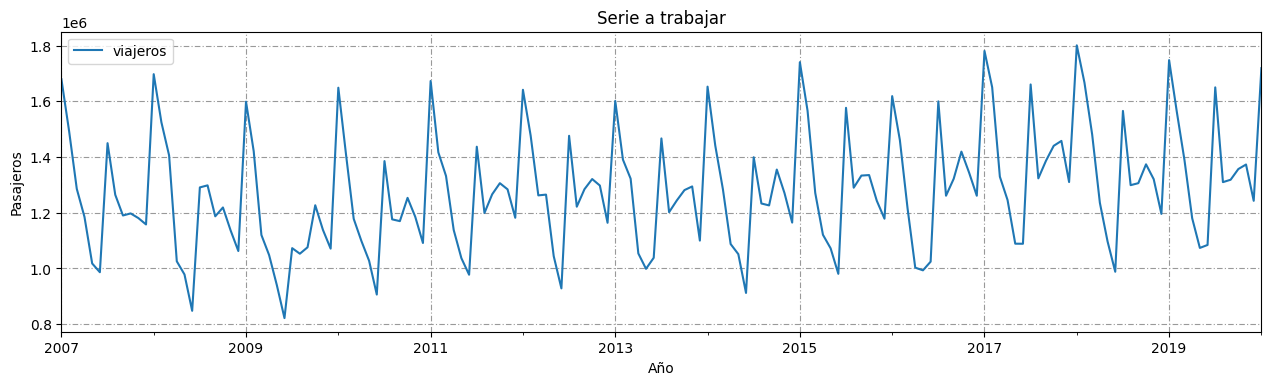

In [ ]:
graficar(serie_residentes, "Serie a trabajar")

In [ ]:
# Separacion Train/Test  ---> esta es otra variable a analizar

train = serie_residentes.iloc[:round(len(serie_residentes)*.8)]

test = serie_residentes.iloc[round(len(serie_residentes)*.8):]
print(train, test)

indice_tiempo
2007-01-01    1679499
2007-02-01    1493372
2007-03-01    1285612
2007-04-01    1184937
2007-05-01    1017821
               ...   
2017-02-01    1650309
2017-03-01    1329411
2017-04-01    1245606
2017-05-01    1088862
2017-06-01    1088614
Freq: MS, Name: viajeros, Length: 126, dtype: int64 indice_tiempo
2017-07-01    1660519
2017-08-01    1323414
2017-09-01    1386911
2017-10-01    1440231
2017-11-01    1457877
2017-12-01    1310199
2018-01-01    1800900
2018-02-01    1666664
2018-03-01    1480667
2018-04-01    1235730
2018-05-01    1097071
2018-06-01     988183
2018-07-01    1565479
2018-08-01    1298976
2018-09-01    1306121
2018-10-01    1373779
2018-11-01    1320392
2018-12-01    1195827
2019-01-01    1747922
2019-02-01    1562882
2019-03-01    1388867
2019-04-01    1180396
2019-05-01    1073666
2019-06-01    1084275
2019-07-01    1650061
2019-08-01    1309835
2019-09-01    1318472
2019-10-01    1356825
2019-11-01    1373087
2019-12-01    1242840
2020-01-01    1719

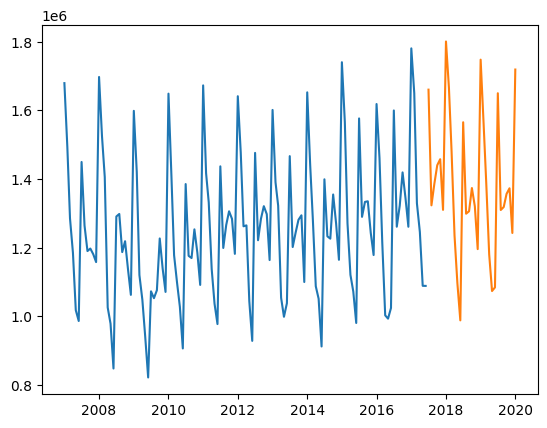

In [ ]:
plt.plot(train)
plt.plot(test)

In [ ]:
len(train)

126

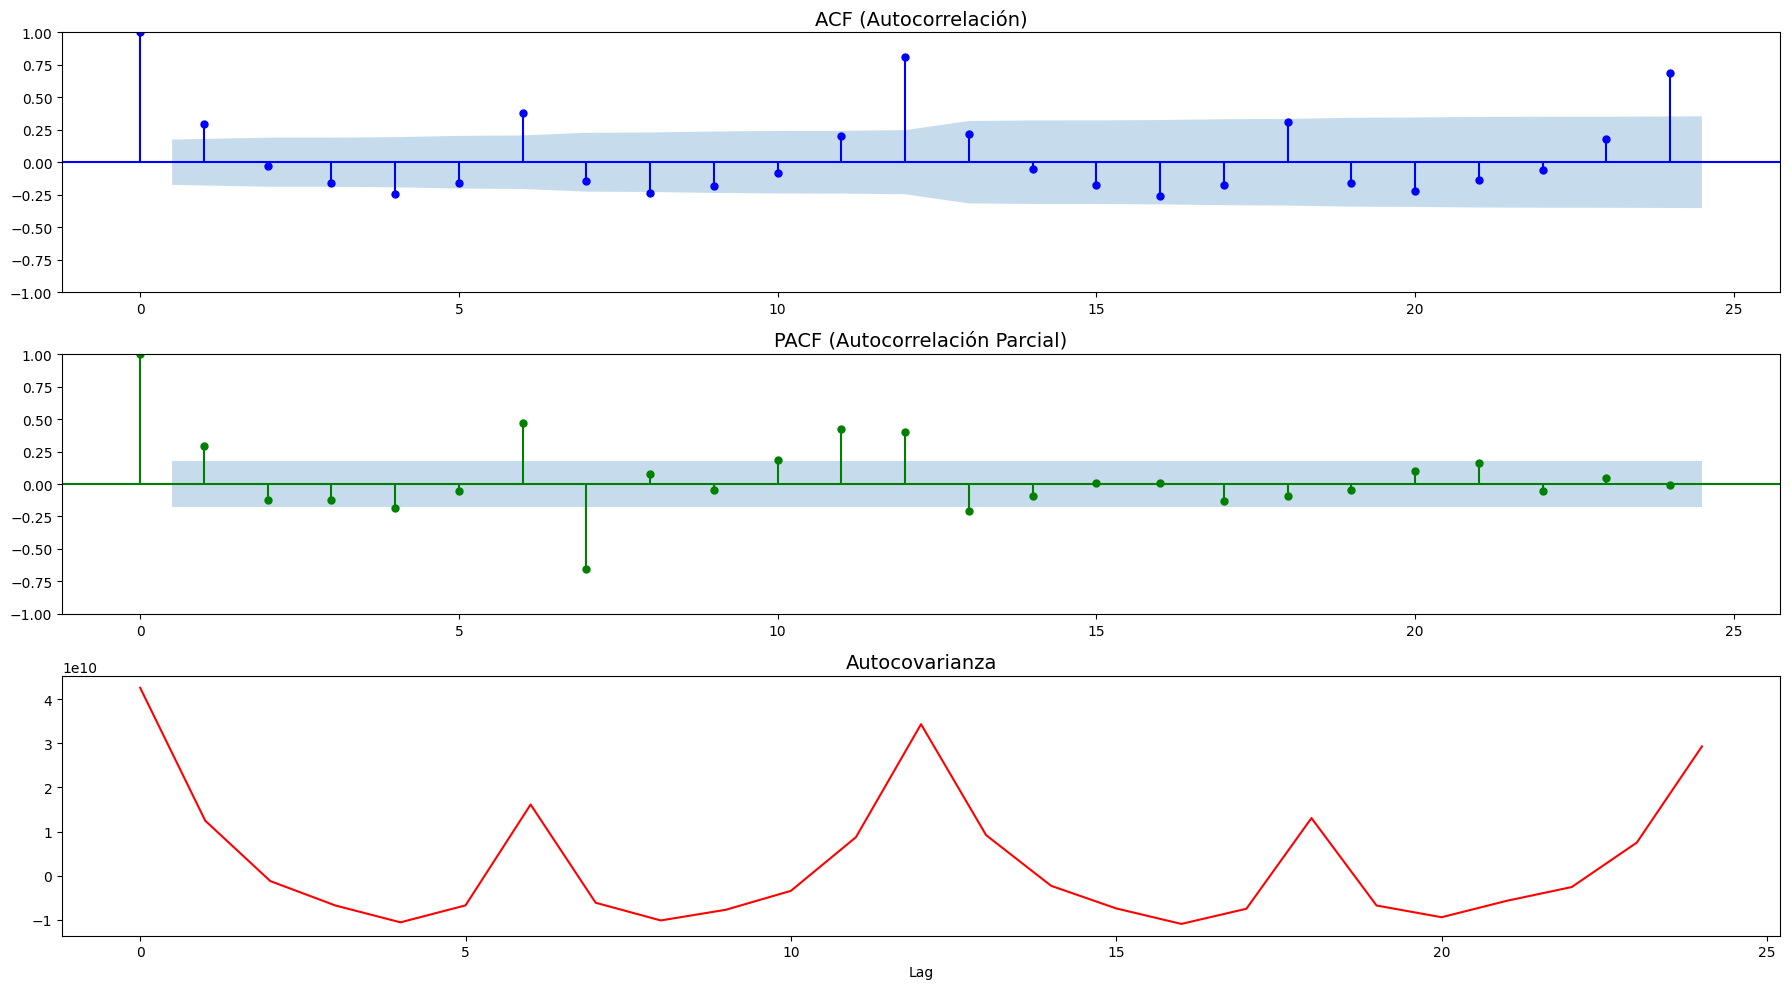

In [ ]:
autocov_autocorr(train ,24)

<Figure size 640x480 with 0 Axes>

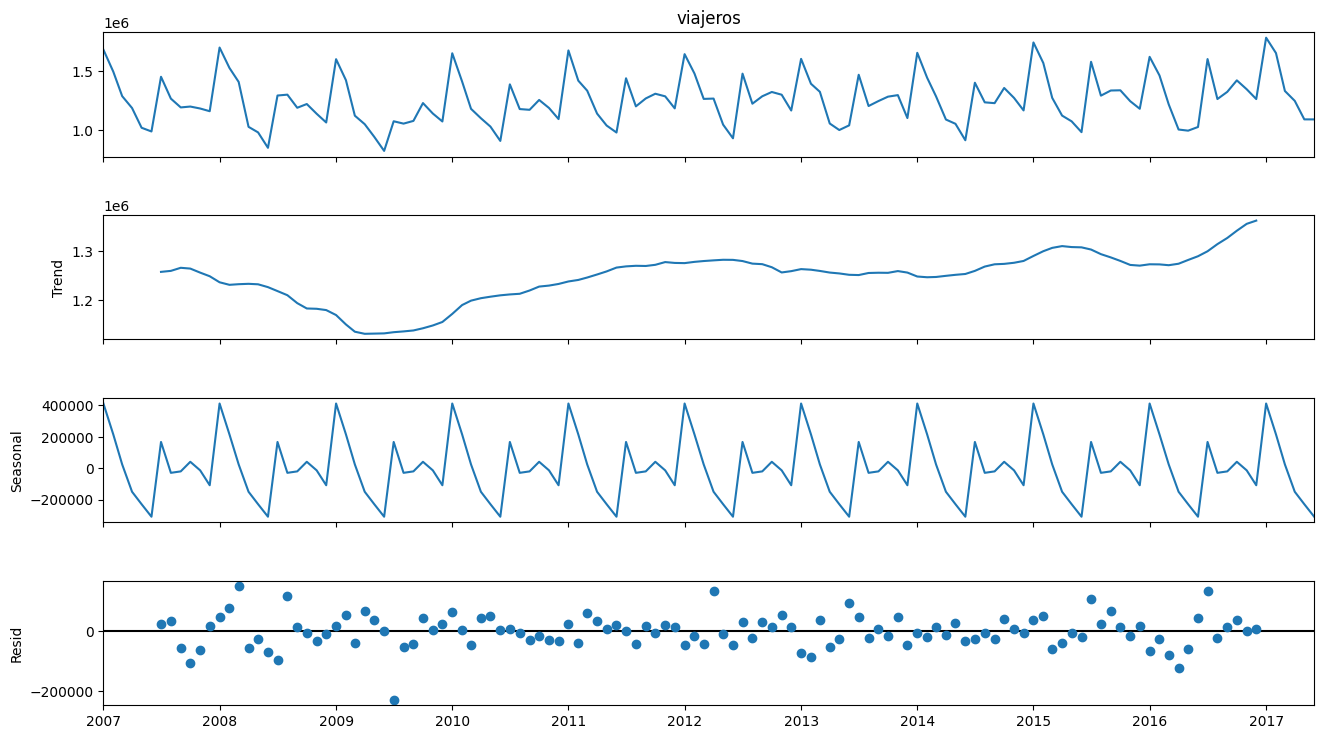

In [ ]:
componentes(train)

In [ ]:
def print_test_afd(y):
  resultado = tsa.adfuller(y)
  print('Estadistico ADF: %f' % resultado[0])
  print('p-valor: %f' % resultado[1])
  print('Valores criticos:')
  for key, valor in resultado[4].items():
    print('\t%s: %.3f' % (key, valor))

In [ ]:
def test_stationarity(timeseries):

    #Rolling statistics -->  ver si la media y desviacion cambian con el tiempoo. si son relativamente constantes la serie podría ser estacionaria
    rolmean = timeseries.rolling(12).mean()
    rolstd = timeseries.rolling(12).std()

    #Plot rolling statistics:
    fig = plt.figure(figsize=(12, 6))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()

Analisis de estacionariedad de las series de residentes

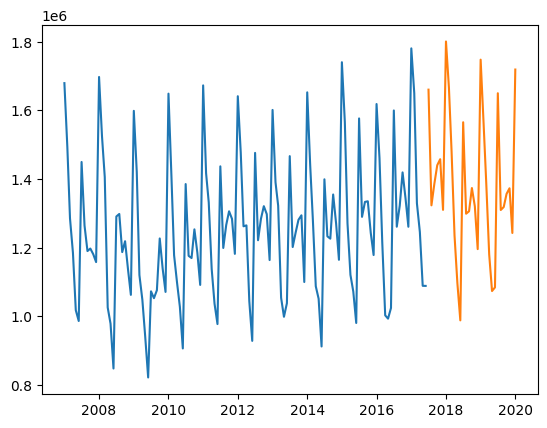

In [ ]:
plt.plot(train)
plt.plot(test)

In [ ]:
print_test_afd(train)

# Para que nuestra serie sea estacionaria, el p-valor debe ser menor a 0.05
# Para rechazar la hip nula (que la serie tiene raiz unitaria) el estadístico debe ser menor que los valores críticos

Estadistico ADF: -0.881054
p-valor: 0.794148
Valores criticos:
	1%: -3.490
	5%: -2.888
	10%: -2.581


https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html

Componentes deterministicos - Test de Raíces Unitarias - Dickey Fuller

In [ ]:
# No incluye termino independiente ni lineal (None)
tsa.adfuller(train, maxlag=None, regression='n', autolag='AIC', store=False, regresults=False)

(np.float64(0.50868060161908),
 np.float64(0.8268648347259111),
 13,
 112,
 {'1%': np.float64(-2.585991642219388),
  '5%': np.float64(-1.9436442461108328),
  '10%': np.float64(-1.614646876252733)},
 np.float64(2864.856711790934))

In [ ]:
# Incluya termino independiente pero no incluye término lineal (Drift)
tsa.adfuller(train, maxlag=None, regression='c', autolag='AIC', store=False, regresults=False)

(np.float64(-0.8810539020175625),
 np.float64(0.7941475969756033),
 13,
 112,
 {'1%': np.float64(-3.4901313156261384),
  '5%': np.float64(-2.8877122815688776),
  '10%': np.float64(-2.5807296460459184)},
 np.float64(2865.923321041762))

In [ ]:
# Incluya ambos terminos (Trend)
tsa.adfuller(train, maxlag=None, regression='ct', autolag='AIC', store=False, regresults=False)

(np.float64(-2.703238559215552),
 np.float64(0.23474033065924355),
 13,
 112,
 {'1%': np.float64(-4.041963001634247),
  '5%': np.float64(-3.4504426407047193),
  '10%': np.float64(-3.1504645425245994)},
 np.float64(2858.2142711627544))

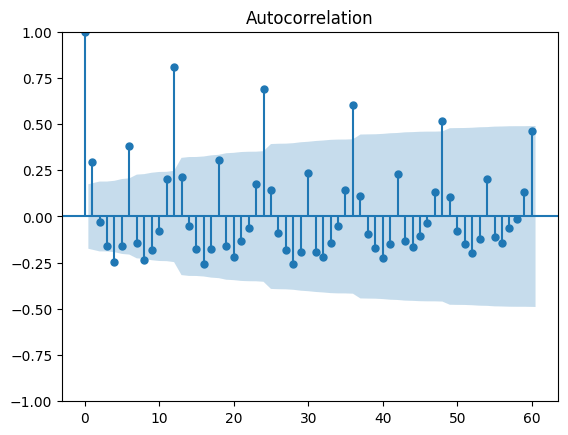

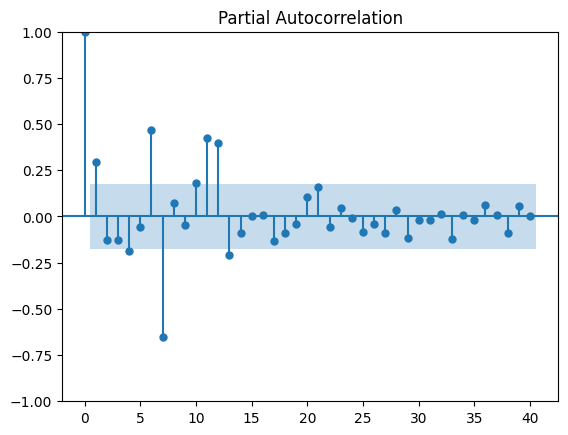

In [ ]:
plot_acf(train,lags=60);
plot_pacf(train,lags=40);

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
import pandas as pd
import numpy as np

def estacionario(y, alpha=0.05, max_d=3):
    y = pd.Series(y).dropna()

    def es_estacionaria(series):
        adf_p = adfuller(series, autolag='AIC')[1]
        try:
            kpss_p = kpss(series, regression='c', nlags="auto")[1]
        except ValueError:
            kpss_p = np.nan
        pp_p = PhillipsPerron(series).pvalue
        return (adf_p < alpha) and (np.isnan(kpss_p) or kpss_p > alpha) and (pp_p < alpha)

    # Resultados originales
    adf_stat, adf_p, *_ = adfuller(y, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(y, regression='c', nlags="auto")
    pp_stat = PhillipsPerron(y).stat
    pp_p = PhillipsPerron(y).pvalue

    print("=== Dickey-Fuller (ADF) ===")
    print(f"Estadistico: {adf_stat:.4f}, p-valor: {adf_p:.4f}")
    print("Serie estacionaria" if adf_p < alpha else "Serie NO estacionaria")

    print("\n=== KPSS ===")
    print(f"Estadistico: {kpss_stat:.4f}, p-valor: {kpss_p:.4f}")
    print("Serie NO estacionaria" if kpss_p < alpha else "Serie estacionaria")

    print("\n=== Phillips-Perron ===")
    print(f"Estadistico: {pp_stat:.4f}, p-valor: {pp_p:.4f}")
    print("Serie estacionaria" if pp_p < alpha else "Serie NO estacionaria")

    d = 0
    temp = y.copy()
    while d < max_d and not es_estacionaria(temp):
        temp = temp.diff().dropna()
        d += 1

    print(f"\nNumero sugerido de diferencias: {d}")
    return d

#  Diferenciacion estacional de la serie original


In [ ]:
serie_residentes_cut_diff_12 = serie_residentes - serie_residentes.shift(12)
serie_residentes_cut_diff_12= serie_residentes_cut_diff_12.dropna()

# Separacion Train/Test

train_diff_12 = serie_residentes_cut_diff_12.iloc[:round(len(serie_residentes_cut_diff_12)*.8)]

test_diff_12 = serie_residentes_cut_diff_12.iloc[round(len(serie_residentes_cut_diff_12)*.8):]


,viajeros
indice_tiempo,
2008-01-01,17966.0
2008-02-01,31277.0
2008-03-01,120279.0
2008-04-01,-159279.0
2008-05-01,-39408.0
...,...
2017-04-01,242807.0
2017-05-01,95670.0
2017-06-01,64267.0


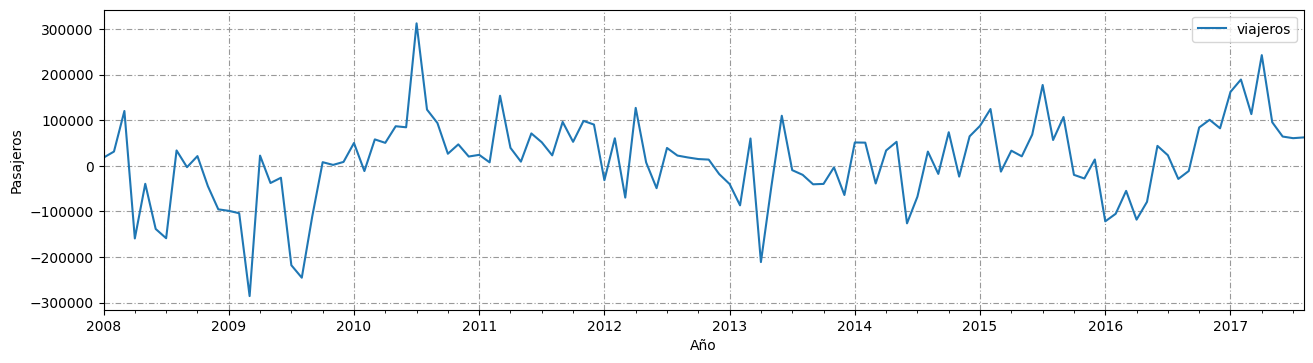

In [ ]:
# Para remover la estacionalidad anual, hacemos una diferencia de 12 meses
graficar(train_diff_12)
train_diff_12

In [ ]:
print_test_afd(train_diff_12)

Estadistico ADF: -2.433472
p-valor: 0.132511
Valores criticos:
	1%: -3.496
	5%: -2.890
	10%: -2.582


In [ ]:
# No incluye termino independiente ni lineal (None)
tsa.adfuller(train_diff_12, maxlag=None, regression='n', autolag='AIC', store=False, regresults=False)

(np.float64(-2.279008366065142),
 np.float64(0.021807284242139423),
 13,
 102,
 {'1%': np.float64(-2.588008223760092),
  '5%': np.float64(-1.9439273444979683),
  '10%': np.float64(-1.614453038574907)},
 np.float64(2585.9889464047874))

In [ ]:
# Incluya termino independiente pero no incluye termino lineal (Drift)
tsa.adfuller(train_diff_12, maxlag=None, regression='c', autolag='AIC', store=False, regresults=False)

(np.float64(-2.4334720489596893),
 np.float64(0.1325111323070971),
 13,
 102,
 {'1%': np.float64(-3.4961490537199116),
  '5%': np.float64(-2.8903209639580556),
  '10%': np.float64(-2.5821223452518263)},
 np.float64(2586.763118615193))

In [ ]:
# Incluya ambos términos (Trend) - se denomina Ecuacion de Dickey Fuller Aumentada
tsa.adfuller(train_diff_12, maxlag=None, regression='ct', autolag='AIC', store=False, regresults=False)

(np.float64(-2.4990704739158875),
 np.float64(0.3284271814990849),
 13,
 102,
 {'1%': np.float64(-4.050384710217036),
  '5%': np.float64(-3.454444406299236),
  '10%': np.float64(-3.1527973675283265)},
 np.float64(2588.2801467521303))

A continuacion, analizamos mediante diferentes pruebas el orden de diferenciacion requerido para que la serie pueda llegar a ser estacionaria. Este es un analizis complementario, junto con los otros realizados. <br>
Las pruebas realizadas son:
<ol>
  <li>Prueba de Dickey-Fuller aumentada</li>
  <li>Prueba de Kwiatkowski-Phillips-Schmidt-Shin</li>
  <li>Prueba de Phillips-Perron</li>
</ol>

In [ ]:
estacionario(train_diff_12)

=== Dickey-Fuller (ADF) ===
Estadistico: -2.4335, p-valor: 0.1325
Serie NO estacionaria

=== KPSS ===
Estadistico: 0.3026, p-valor: 0.1000
Serie estacionaria

=== Phillips-Perron ===
Estadistico: -7.3448, p-valor: 0.0000
Serie estacionaria

Numero sugerido de diferencias: 1


/tmp/ipykernel_1663/2006786665.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(y, regression='c', nlags="auto")
/tmp/ipykernel_1663/2006786665.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, regression='c', nlags="auto")[1]
/tmp/ipykernel_1663/2006786665.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, regression='c', nlags="auto")[1]


1

KPSS
Estadístico = 0.3026, p-valor = 0.1000. La hip nula del KPSS es que la serie es estacionaria.Aca el p-valor > 0.05 asi que no rechazamos la hip nula.

Conclusion KPSS: Serie estacionaria

Phillips-Perron (PP)
Estadistico = -7.3448, p-valor = 0.0000. La hip 0 es la misma que ADF (raiz unitaria --> no estacionaria). Aca el p-valor es muy bajo por lo que rechazamos la hip nula.
Conclusion PP: Serie estacionaria

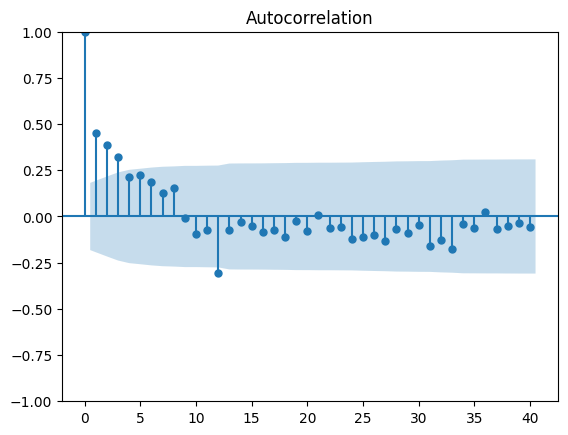

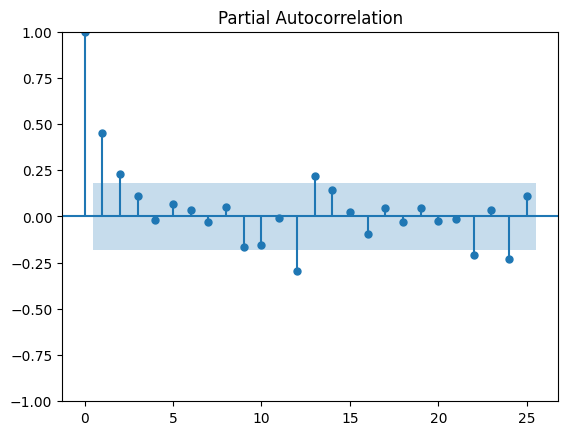

In [ ]:
plot_acf(train_diff_12,lags=40);
plot_pacf(train_diff_12,lags=25);

Realizamos una primera diferencia de la serie original

In [ ]:
serie_residentes_cut_diff_1 = serie_residentes - serie_residentes.shift(1)
serie_residentes_cut_diff_1= serie_residentes_cut_diff_1.dropna()

# Separacion Train/Test
train_diff_1 = serie_residentes_cut_diff_1.iloc[:round(len(serie_residentes_cut_diff_1)*.8)]
test_diff_1 = serie_residentes_cut_diff_1.iloc[round(len(serie_residentes_cut_diff_1)*.8):]


indice_tiempo
2007-02-01   -186127.0
2007-03-01   -207760.0
2007-04-01   -100675.0
2007-05-01   -167116.0
2007-06-01    -31433.0
                ...   
2017-02-01   -130508.0
2017-03-01   -320898.0
2017-04-01    -83805.0
2017-05-01   -156744.0
2017-06-01      -248.0
Freq: MS, Name: viajeros, Length: 125, dtype: float64


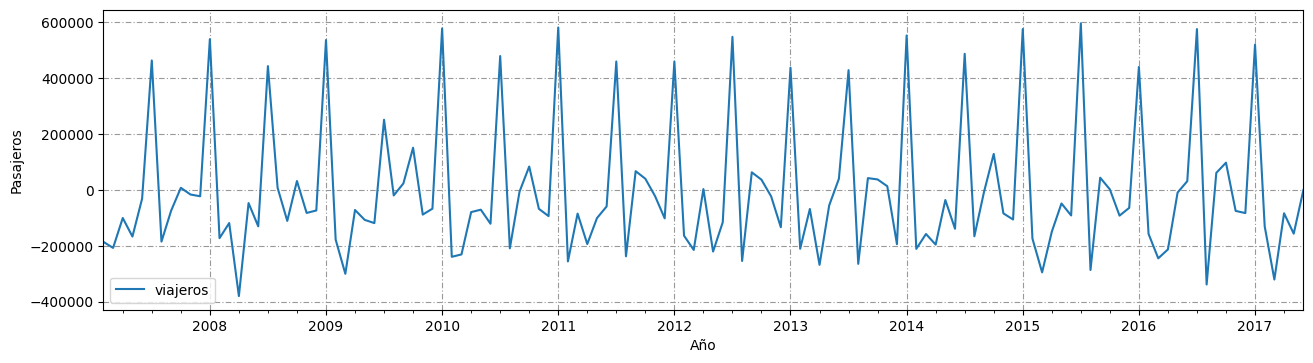

In [ ]:
graficar(train_diff_1)
print(train_diff_1)

In [ ]:
print_test_afd(train_diff_1)

Estadistico ADF: -3.885039
p-valor: 0.002148
Valores criticos:
	1%: -3.490
	5%: -2.888
	10%: -2.581


In [ ]:
# No incluye termino independiente ni lineal (“None”)
tsa.adfuller(train_diff_1, maxlag=None, regression='n', autolag='AIC', store=False, regresults=False)

(np.float64(-3.860768600713069),
 np.float64(0.0001260637640177667),
 12,
 112,
 {'1%': np.float64(-2.585991642219388),
  '5%': np.float64(-1.9436442461108328),
  '10%': np.float64(-1.614646876252733)},
 np.float64(2837.2534475407588))

In [ ]:
# Incluya termino independiente pero no incluye termino lineal (Drift)
tsa.adfuller(train_diff_1, maxlag=None, regression='c', autolag='AIC', store=False, regresults=False)

(np.float64(-3.8850385223792543),
 np.float64(0.002147756420929405),
 12,
 112,
 {'1%': np.float64(-3.4901313156261384),
  '5%': np.float64(-2.8877122815688776),
  '10%': np.float64(-2.5807296460459184)},
 np.float64(2839.0313942043726))

In [ ]:
# Incluya ambos terminos (“Trend”) - se denomina Ecuación de Dickey Fuller Aumentada
tsa.adfuller(train_diff_1, maxlag=None, regression='ct', autolag='AIC', store=False, regresults=False)

(np.float64(-4.158091855110128),
 np.float64(0.0051747658613272626),
 12,
 112,
 {'1%': np.float64(-4.041963001634247),
  '5%': np.float64(-3.4504426407047193),
  '10%': np.float64(-3.1504645425245994)},
 np.float64(2837.7921334952284))

In [ ]:
estacionario(train_diff_1)

=== Dickey-Fuller (ADF) ===
Estadistico: -3.8850, p-valor: 0.0021
Serie estacionaria

=== KPSS ===
Estadistico: 0.1053, p-valor: 0.1000
Serie estacionaria

=== Phillips-Perron ===
Estadistico: -24.7908, p-valor: 0.0000
Serie estacionaria

Numero sugerido de diferencias: 0


/tmp/ipykernel_1663/2006786665.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(y, regression='c', nlags="auto")
/tmp/ipykernel_1663/2006786665.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, regression='c', nlags="auto")[1]


0

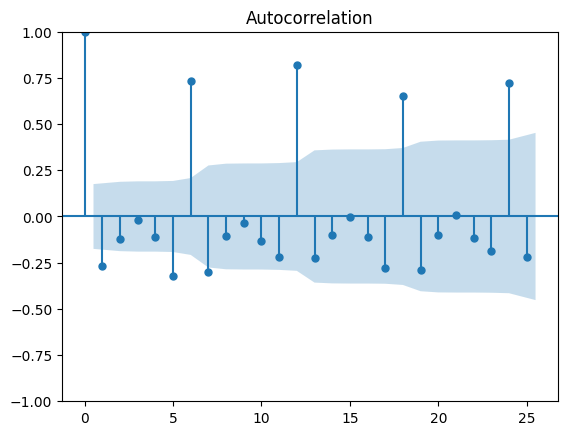

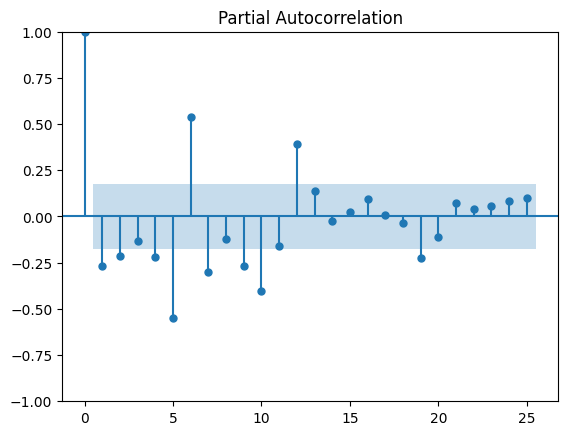

In [ ]:
plot_acf(train_diff_1,lags=25);
plot_pacf(train_diff_1,lags=25);



Ahora vemos la grafica de ACF y PACF para la serie diferenciada en orden 1 de Residentes, se observan picos, lo cual es un indicativo de estacionalidad.

Diferenciamos estacionalmente la serie diferenciada

In [ ]:
serie_residentes_cut_diff_1_12 = serie_residentes_cut_diff_1 - serie_residentes_cut_diff_1.shift(12)
serie_residentes_cut_diff_1_12= serie_residentes_cut_diff_1_12.dropna()

# Separacion Train/Test
train_diff_1_12 = serie_residentes_cut_diff_1_12.iloc[:round(len(serie_residentes_cut_diff_1_12)*.8)]
test_diff_1_12 = serie_residentes_cut_diff_1_12.iloc[round(len(serie_residentes_cut_diff_1_12)*.8):]

,viajeros
indice_tiempo,
2008-02-01,13311.0
2008-03-01,89002.0
2008-04-01,-279558.0
2008-05-01,119871.0
2008-06-01,-99089.0
...,...
2017-04-01,129337.0
2017-05-01,-147137.0
2017-06-01,-31403.0


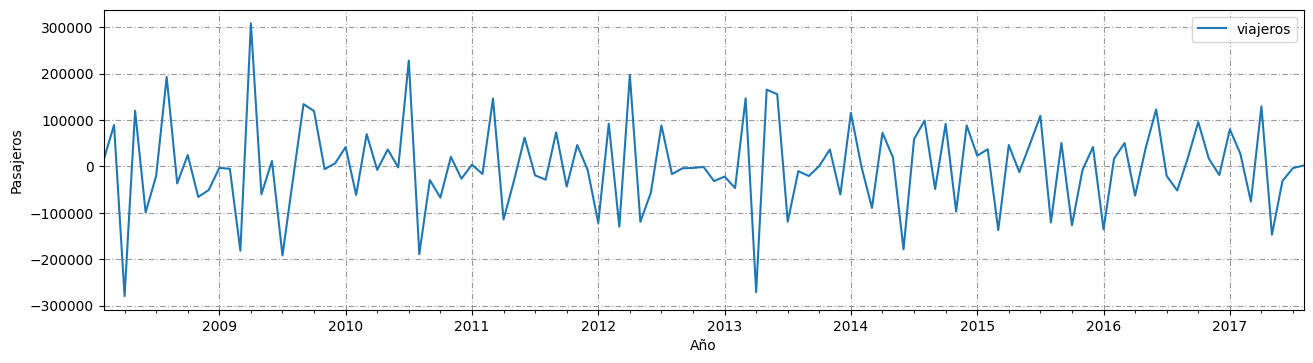

In [ ]:
# Para remover la estacionalidad anual, hacemos una diferencia de 12 meses y en el grafico ya no observamos un patron tan marcado


graficar(train_diff_1_12)
train_diff_1_12

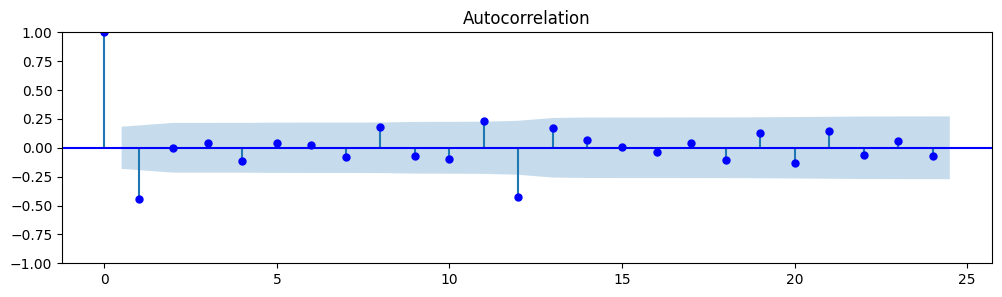

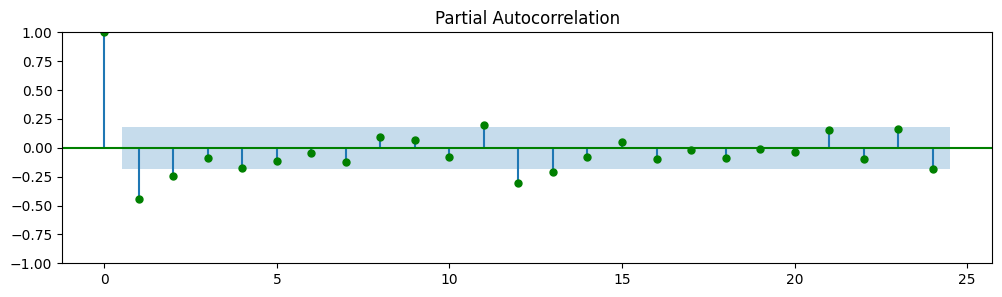

In [ ]:
acf_plot = plot_acf(train_diff_1_12, lags=24, color= 'blue')
pacf_plot = plot_pacf(train_diff_1_12, lags=24, color= 'green')

pacf_plot.set_size_inches(12,3)
acf_plot.set_size_inches(12,3)

In [ ]:
print_test_afd(train_diff_1_12)

Estadistico ADF: -4.487201
p-valor: 0.000207
Valores criticos:
	1%: -3.496
	5%: -2.890
	10%: -2.582


In [ ]:
# No incluye término independiente ni lineal (“None”)
tsa.adfuller(train_diff_1_12, maxlag=None, regression='n', autolag='AIC', store=False, regresults=False)

(np.float64(-4.47148903593267),
 np.float64(1.0656259835701633e-05),
 12,
 102,
 {'1%': np.float64(-2.588008223760092),
  '5%': np.float64(-1.9439273444979683),
  '10%': np.float64(-1.614453038574907)},
 np.float64(2559.9418175632445))

In [ ]:
# Incluya término independiente pero no incluye término lineal (“Drift”)
tsa.adfuller(train_diff_1_12, maxlag=None, regression='c', autolag='AIC', store=False, regresults=False)

(np.float64(-4.487200735362384),
 np.float64(0.00020738083161237188),
 12,
 102,
 {'1%': np.float64(-3.4961490537199116),
  '5%': np.float64(-2.8903209639580556),
  '10%': np.float64(-2.5821223452518263)},
 np.float64(2561.16892023002))

In [ ]:
# Incluya ambos términos (“Trend”) - se denomina Ecuación de Dickey Fuller Aumentada
tsa.adfuller(train_diff_1_12, maxlag=None, regression='ct', autolag='AIC', store=False, regresults=False)

(np.float64(-4.435162759710347),
 np.float64(0.0019232910748465406),
 12,
 102,
 {'1%': np.float64(-4.050384710217036),
  '5%': np.float64(-3.454444406299236),
  '10%': np.float64(-3.1527973675283265)},
 np.float64(2562.71032554374))

In [ ]:
estacionario(train_diff_1_12)

=== Dickey-Fuller (ADF) ===
Estadistico: -4.4872, p-valor: 0.0002
Serie estacionaria

=== KPSS ===
Estadistico: 0.0936, p-valor: 0.1000
Serie estacionaria

=== Phillips-Perron ===
Estadistico: -26.1458, p-valor: 0.0000
Serie estacionaria

Numero sugerido de diferencias: 0


/tmp/ipykernel_1663/2006786665.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(y, regression='c', nlags="auto")
/tmp/ipykernel_1663/2006786665.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, regression='c', nlags="auto")[1]


0

In [ ]:
# Funcion para graficar las predicciones.
# Toma como parametros:
# serie_test: la porcion de la serie con los datos de test
# serie_pred: las predicciones hechas por el modelo
# conf_int: el intervalo de confianza de las predicciones

def graficar_pred(serie_test, serie_pred, conf_int, titulo="Valores Originales vs Predicciones", xlabel="Año", ylabel="Pasajeros"):
    fig_x = plt.figure(figsize=(12,3), dpi=100)
    axes_x = fig_x.add_axes([0.0, 0.0, 1, 1])


    serie_test.plot(label="Serie Original de Test")
    serie_pred.plot(label="Predicciones")


    conf_int.iloc[:,1].plot(label="Intervalo de Confianza Superior")
    conf_int.iloc[:,0].plot(label="Intervalo de Confianza Inferior")

    axes_x.set_xlabel(xlabel)
    axes_x.set_ylabel(ylabel)
    axes_x.set_title(titulo)
    axes_x.legend(loc=0)
    axes_x.grid(True, color='0.6', dashes=(5,2,1,2))

In [ ]:
def evaluar_metricas(serie_test, serie_pred):
    print(f'MSE: {mean_squared_error(serie_test, serie_pred)}')
    print(f'MAE: {mean_absolute_error(serie_test, serie_pred)}')
    print(f'RMSE: {np.sqrt(mean_squared_error(serie_test, serie_pred))}')
    print(f'MAPE: {round(np.mean(abs((serie_test-serie_pred)/serie_test)),4)}')

# MODELOS

MODELO ARMA

In [ ]:
# Aqui hacemos el loop probando diferentes "p" y "q" para saber cual es el criterio de informacion mas bajo.

import itertools
import statsmodels.api as sm

p_values = range(0, 3)
q_values = range(0, 3)


resultados = []
mejor_aic = float("inf")
mejor_order = None
mejor_modelo = None


for p, q in itertools.product(p_values, q_values):
    try:

        modelo = sm.tsa.arima.ARIMA(train_diff_1_12, order=(p, 0, q))  # aca pueden poner la serie a analizar
        resultado = modelo.fit()

        aic = resultado.aic
        resultados.append((p, q, aic))

        if aic < mejor_aic:
            mejor_aic = aic
            mejor_order = (p, q)
            mejor_modelo = resultado

    except Exception as e:
        print(f"Error en el modelo ARMA({p},{q}): {e}")

print(f"Mejor modelo ARMA: order={mejor_order} con AIC={mejor_aic}")

for p, q, aic in resultados:
    print(f"ARMA({p},{q}) AIC: {aic}")


Mejor modelo ARMA: order=(1, 2) con AIC=2933.7460660323204
ARMA(0,0) AIC: 3401.570015894159
ARMA(0,1) AIC: 2935.423501510881
ARMA(0,2) AIC: 2937.2204296818145
ARMA(1,0) AIC: 2947.2098159464676
ARMA(1,1) AIC: 2936.9562904705163
ARMA(1,2) AIC: 2933.7460660323204
ARMA(2,0) AIC: 2942.2600563946794
ARMA(2,1) AIC: 2934.7703138291754
ARMA(2,2) AIC: 2935.685443465266


In [ ]:
from statsmodels.tsa.arima_model import ARMA

import statsmodels.api as sm
modeloARMA = sm.tsa.arima.ARIMA(train_diff_1_12, order=((1,0,2)))
resultadoARMA = modeloARMA.fit()

print(resultadoARMA.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               viajeros   No. Observations:                  115
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -1461.873
Date:                Sat, 21 Mar 2026   AIC                           2933.746
Time:                        00:57:47   BIC                           2947.471
Sample:                    02-01-2008   HQIC                          2939.317
                         - 08-01-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        386.0682    653.311      0.591      0.555    -894.398    1666.534
ar.L1          0.8214      0.143      5.760      0.000       0.542       1.101
ma.L1         -1.4930      0.189     -7.882      0.000      -1.864      -1.122
ma.L2          0.4933      0.185      2.669      0.008       0.131       0.856
sigma2      6.351e+09   7.92e-06   8.02e+14      0.000    6.35e+09    6.35e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 5.79
Prob(Q):                              0.87   Prob(JB):                         0.06
Heteroskedasticity (H):               0.47   Skew:                            -0.13
Prob(H) (two-sided):                  0.02   Kurtosis:                         4.07
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.59e+31. Standard errors may be unstable.
"""

In [ ]:
# Vemos que el componente "const" da un "p>Z" en modulo mayor a 0.05. Por lo tanto lo eliminamos

modeloARMA = sm.tsa.arima.ARIMA(train_diff_1_12, order=(1,0,2), trend='n')
resultadoARMA_2 = modeloARMA.fit()


print(resultadoARMA_2.summary())

                               SARIMAX Results                                
Dep. Variable:               viajeros   No. Observations:                  115
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -1462.387
Date:                Sat, 21 Mar 2026   AIC                           2932.774
Time:                        00:59:11   BIC                           2943.754
Sample:                    02-01-2008   HQIC                          2937.231
                         - 08-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8478      0.125      6.778      0.000       0.603       1.093
ma.L1         -1.5100      0.178     -8.492      0.000      -1.859      -1.161
ma.L2          0.5103      0.170      3.010      0.0

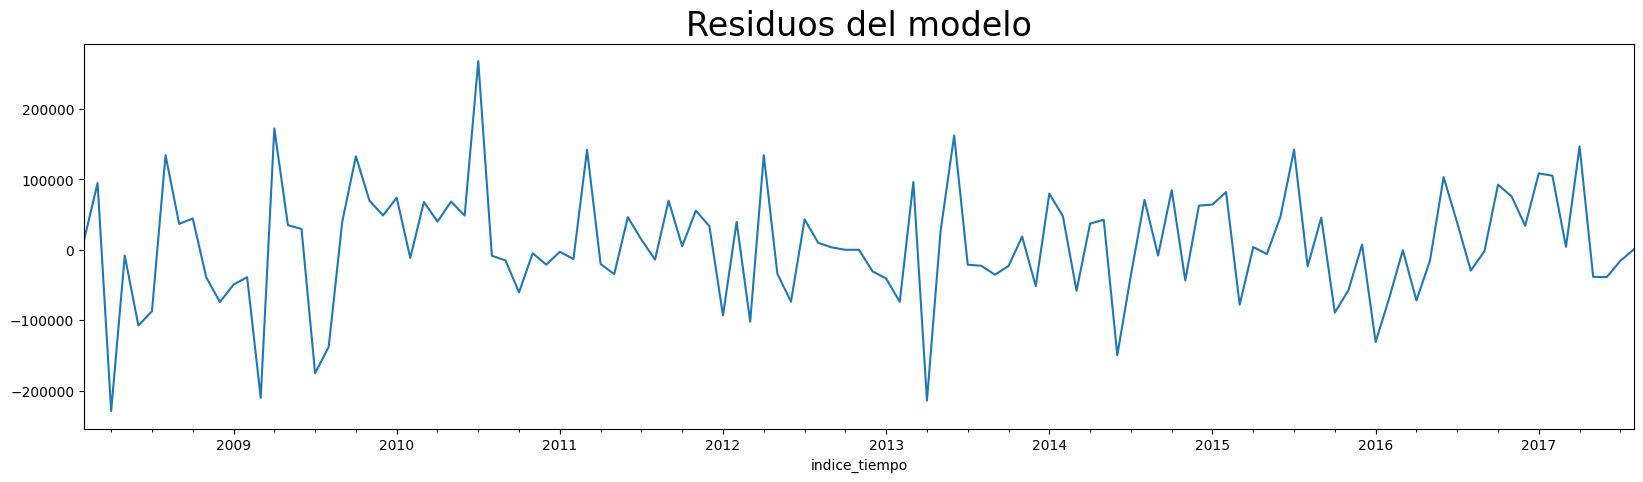

In [ ]:
resultadoARMA_2.resid.plot(figsize=(20,5))
plt.title("Residuos del modelo",size=24)
plt.show()

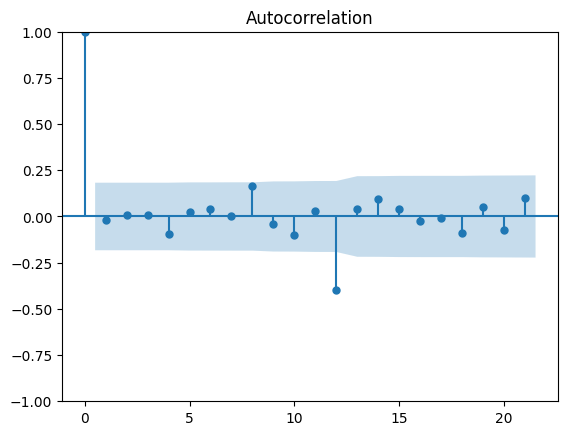

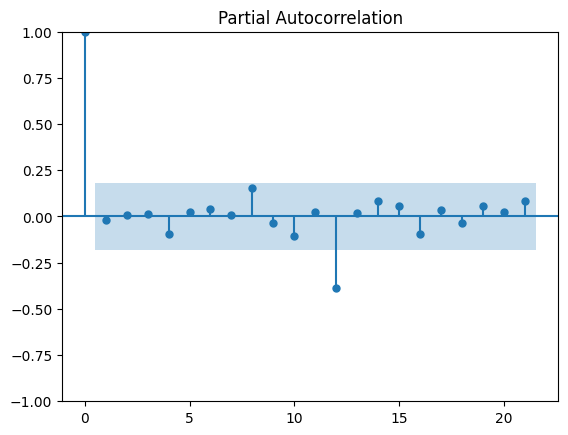

In [ ]:
plot_acf(resultadoARMA_2.resid);
plot_pacf(resultadoARMA_2.resid);

Text(0, 0.5, 'P-valores ')

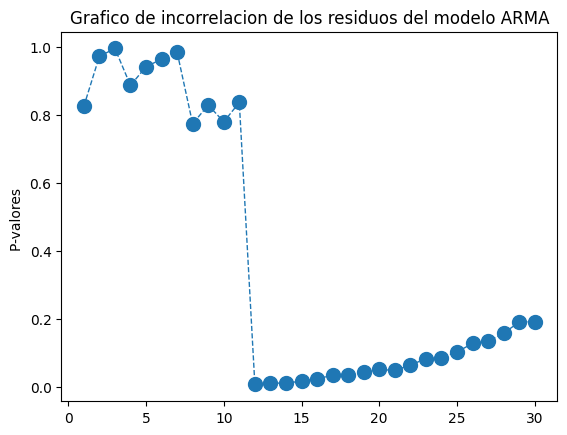

In [ ]:
Incorr_residuos_modelo_ARMA=sm.stats.acorr_ljungbox(resultadoARMA_2.resid, lags=30)
plt.plot(Incorr_residuos_modelo_ARMA.lb_pvalue, marker='o', markersize=10, linestyle='--', linewidth=1)
plt.title("Grafico de incorrelacion de los residuos del modelo ARMA")
plt.ylabel("P-valores ")

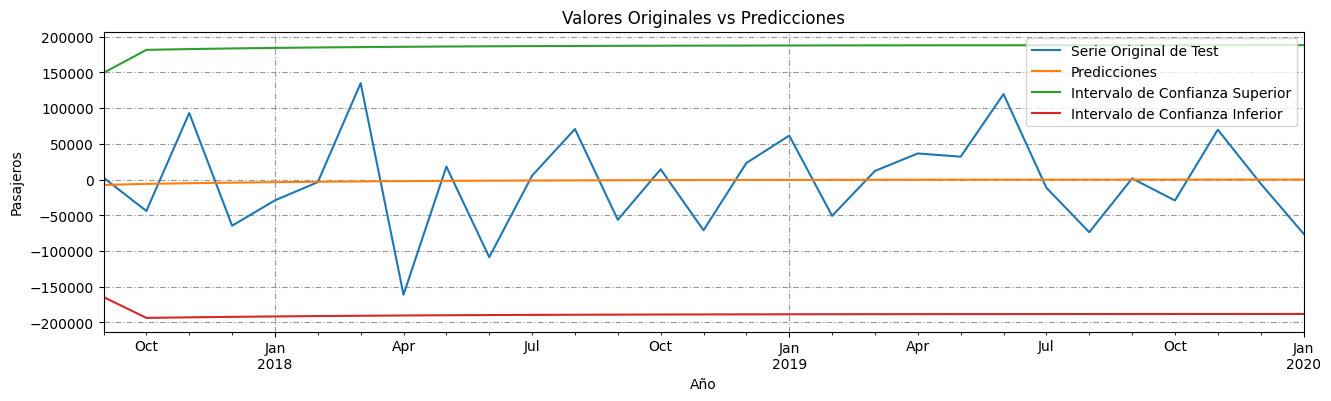

In [ ]:
# Utilizando el modelo realizamos la prediccion correspondiente al periodo de test
prediccionesARMA = resultadoARMA_2.get_forecast(len(test_diff_1_12))

# Graficamos la porcion de test de la serie original junto con las predicciones y los intervalos de confianza
graficar_pred(test_diff_1_12, prediccionesARMA.predicted_mean, prediccionesARMA.conf_int())

In [ ]:
evaluar_metricas(test_diff_1_12, prediccionesARMA.predicted_mean)

MSE: 4335870023.350275
MAE: 51006.74911215286
RMSE: 65847.3235853233
MAPE: 1.0817


**ARMA con otras transformaciones de la serie original - Vemos que arroja peores resultados.**

Recordando que esta seleccion de la serie transformada no es correcta si queremos trabajar con un modelo ARMA.

Problemas=
1- tendencia y la  2- estacionalidad. eso hace q las series no sean estacionarias. Entonces hay q quitar esos picos para q las series sean estacionarias.

El modelo ARMA es con datos estacionarios.

In [ ]:
import itertools
import statsmodels.api as sm

p_values = range(0, 3)
q_values = range(0, 3)

resultados = []
mejor_aic = float("inf")
mejor_order = None
mejor_modelo = None

for p, q in itertools.product(p_values, q_values):
    try:

        modelo = sm.tsa.arima.ARIMA(train_diff_1, order=(p, 0, q))
        resultado = modelo.fit()

        aic = resultado.aic
        resultados.append((p, q, aic))

        if aic < mejor_aic:
            mejor_aic = aic
            mejor_order = (p, q)
            mejor_modelo = resultado

    except Exception as e:
        print(f"Error en el modelo ARMA({p},{q}): {e}")

print(f"Mejor modelo ARMA: order={mejor_order} con AIC={mejor_aic}")

for p, q, aic in resultados:
    print(f"ARMA({p},{q}) AIC: {aic}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Mejor modelo ARMA: order=(0, 2) con AIC=3422.99801110757
ARMA(0,0) AIC: 3938.3813818438416
ARMA(0,1) AIC: 3433.6951856676487
ARMA(0,2) AIC: 3422.99801110757
ARMA(1,0) AIC: 3451.398773932806
ARMA(1,1) AIC: 3425.494038971884
ARMA(1,2) AIC: 3433.578378306127
ARMA(2,0) AIC: 3447.5191149696293
ARMA(2,1) AIC: 3426.302923065493
ARMA(2,2) AIC: 3428.7544422797005


In [ ]:
from statsmodels.tsa.arima_model import ARMA

import statsmodels.api as sm
modeloARMA = sm.tsa.arima.ARIMA(train_diff_1, order=(0,0,2))
resultadoARMA = modeloARMA.fit()

resultadoARMA.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               viajeros   No. Observations:                  125
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1707.499
Date:                Thu, 19 Mar 2026   AIC                           3422.998
Time:                        14:44:48   BIC                           3434.311
Sample:                    02-01-2007   HQIC                          3427.594
                         - 06-01-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4727.0799   3937.392     -1.201      0.230   -1.24e+04    2990.067
ma.L1         -0.5859      0.145     -4.033      0.000      -0.871      -0.301
ma.L2         -0.2825      0.155     -1.827      0.068      -0.586       0.021
sigma2      4.337e+10      0.002   2.27e+13      0.000    4.34e+10    4.34e+10
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                20.53
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               1.15   Skew:                             0.96
Prob(H) (two-sided):                  0.65   Kurtosis:                         3.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.76e+31. Standard errors may be unstable.
"""

In [ ]:
from statsmodels.tsa.arima_model import ARMA

import statsmodels.api as sm
modeloARMA = sm.tsa.arima.ARIMA(train_diff_1, order=(0,0,1), trend='n')
resultadoARMA = modeloARMA.fit()

resultadoARMA.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               viajeros   No. Observations:                  125
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1710.665
Date:                Thu, 19 Mar 2026   AIC                           3425.329
Time:                        14:44:54   BIC                           3430.986
Sample:                    02-01-2007   HQIC                          3427.627
                         - 06-01-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9701      0.045    -21.697      0.000      -1.058      -0.882
sigma2      5.236e+10   5.91e-15   8.86e+24      0.000    5.24e+10    5.24e+10
===================================================================================
Ljung-Box (L1) (Q):                  11.67   Jarque-Bera (JB):                 4.43
Prob(Q):                              0.00   Prob(JB):                         0.11
Heteroskedasticity (H):               0.99   Skew:                             0.45
Prob(H) (two-sided):                  0.96   Kurtosis:                         2.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number    inf. Standard errors may be unstable.
"""

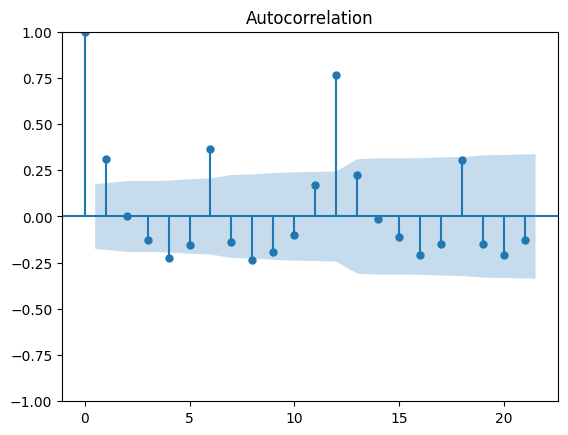

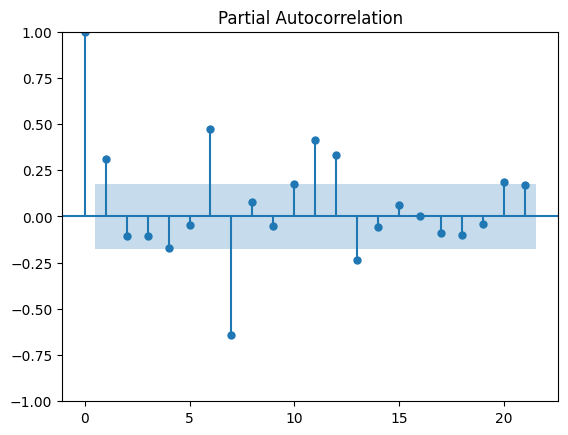

In [ ]:
plot_acf(resultadoARMA.resid);
plot_pacf(resultadoARMA.resid);

Text(0, 0.5, 'P-valores ')

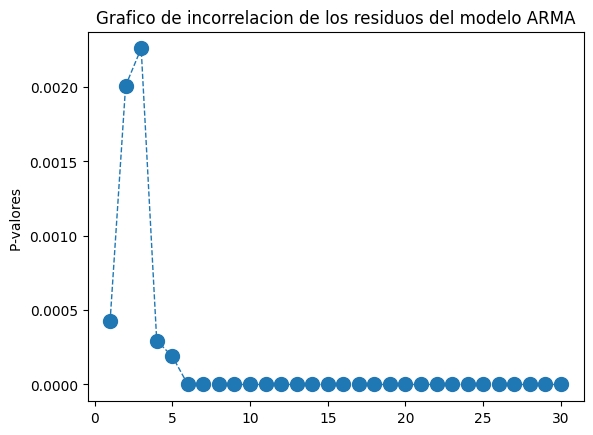

In [ ]:
Incorr_residuos_modelo_ARMA=sm.stats.acorr_ljungbox(resultadoARMA.resid, lags=30)
plt.plot(Incorr_residuos_modelo_ARMA.lb_pvalue, marker='o', markersize=10, linestyle='--', linewidth=1)
plt.title("Grafico de incorrelacion de los residuos del modelo ARMA")
plt.ylabel("P-valores ")

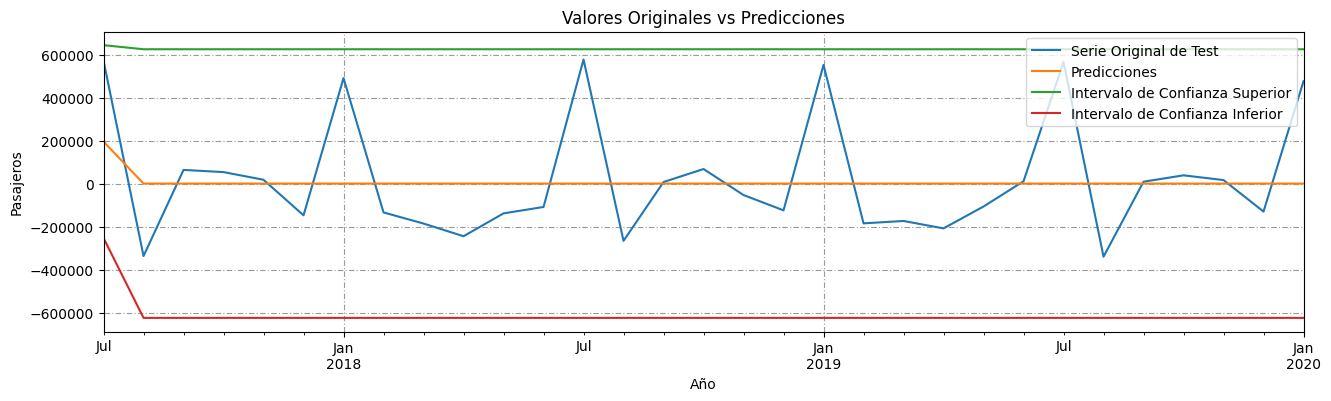

In [ ]:
# Utilizando el modelo realizamos la prediccion correspondiente al periodo de test
prediccionesARMA = resultadoARMA.get_forecast(len(test_diff_1))

# Graficamos la porcion de test de la serie original junto con las predicciones y los intervalos de confianza
graficar_pred(test_diff_1, prediccionesARMA.predicted_mean, prediccionesARMA.conf_int())

In [ ]:
evaluar_metricas(test_diff_1, prediccionesARMA.predicted_mean)

MSE: 71031187810.03993
MAE: 200274.46474876153
RMSE: 266516.76834683394
MAPE: 0.989


Hasta ahora, el modelo anterior es mejor porque tiene un MSE, RMSE y MAE mucho menores que este ultimo modelo lo que indica una mejor capacidad predictiva en términos absolutos.

# MODELO SARIMA

In [ ]:
import itertools
import statsmodels.api as sm

# Rango ARIMA para probar
p_values = range(0, 3)
d_values = [0, 1]
q_values = range(0, 3)

# Rango Estacional para probar
P_values = range(0, 3)  # P
D_values = [0, 1]       # D
Q_values = range(0, 3)  # Q
s = 12                  # Periodo estacional (ej: 12 para mensual con estacionalidad anual)

resultados = []
mejor_aic = float("inf")
mejor_order = None
mejor_seasonal_order = None
mejor_modelo = None

for p, d, q, P, D, Q in itertools.product(p_values, d_values, q_values,
                                          P_values, D_values, Q_values):
    try:
        modelo = sm.tsa.statespace.SARIMAX(
            train,                      # <-- acá va tu serie
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        resultado = modelo.fit(disp=False)
        aic = resultado.aic
        resultados.append(((p, d, q), (P, D, Q, s), aic))

        if aic < mejor_aic:
            mejor_aic = aic
            mejor_order = (p, d, q)
            mejor_seasonal_order = (P, D, Q, s)
            mejor_modelo = resultado

    except Exception as e:
        print(f"Error en SARIMA({p},{d},{q})x({P},{D},{Q},{s}): {e}")

# Mostrar mejor modelo
print(f"\nMejor modelo SARIMA: order={mejor_order}, seasonal_order={mejor_seasonal_order} con AIC={mejor_aic}")

# Top 5 modelos por AIC
print("\nTop 5 modelos por AIC:")
for order, seasonal_order, aic in sorted(resultados, key=lambda x: x[2])[:5]:
    print(f"SARIMA{order}x{seasonal_order} - AIC: {aic}")


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


Mejor modelo SARIMA: order=(0, 1, 2), seasonal_order=(0, 1, 2, 12) con AIC=2159.9564972986423

Top 5 modelos por AIC:
SARIMA(0, 1, 2)x(0, 1, 2, 12) - AIC: 2159.9564972986423
SARIMA(0, 1, 2)x(1, 1, 2, 12) - AIC: 2161.39931872213
SARIMA(0, 1, 2)x(2, 1, 2, 12) - AIC: 2161.5256920541983
SARIMA(1, 1, 2)x(0, 1, 2, 12) - AIC: 2161.833525501599
SARIMA(1, 1, 2)x(2, 1, 2, 12) - AIC: 2161.859329338307


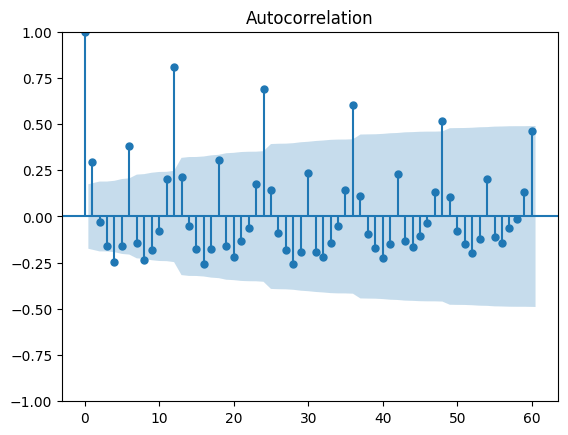

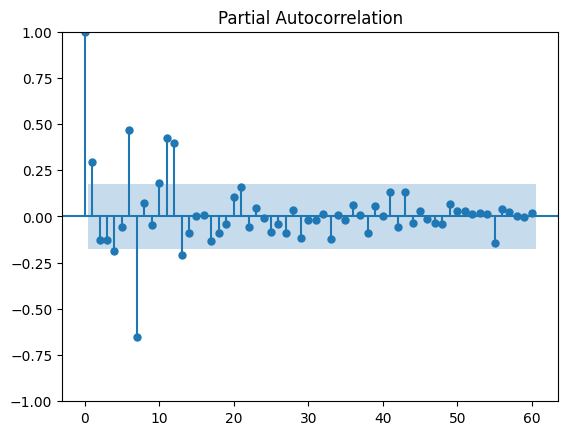

In [ ]:
plot_acf(train,lags=60);
plot_pacf(train,lags=60);

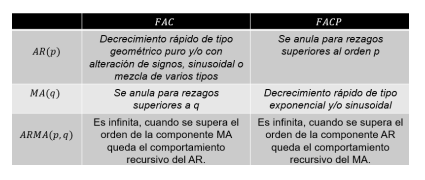

Modelo 3 . SARIMA

In [ ]:
modeloSARIMA2 = SARIMAX(train, order=(0,1,2), seasonal_order=(0,1,2,12))
modeloSARIMA2_fit = modeloSARIMA2.fit()
print(modeloSARIMA2_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                           viajeros   No. Observations:                  126
Model:             SARIMAX(0, 1, 2)x(0, 1, 2, 12)   Log Likelihood               -1440.056
Date:                            Thu, 19 Mar 2026   AIC                           2890.112
Time:                                    14:51:11   BIC                           2903.749
Sample:                                01-01-2007   HQIC                          2895.645
                                     - 06-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1987      0.050     -3.955      0.000      -0.297      -0.100
ma.L2          0.0853      0.062   

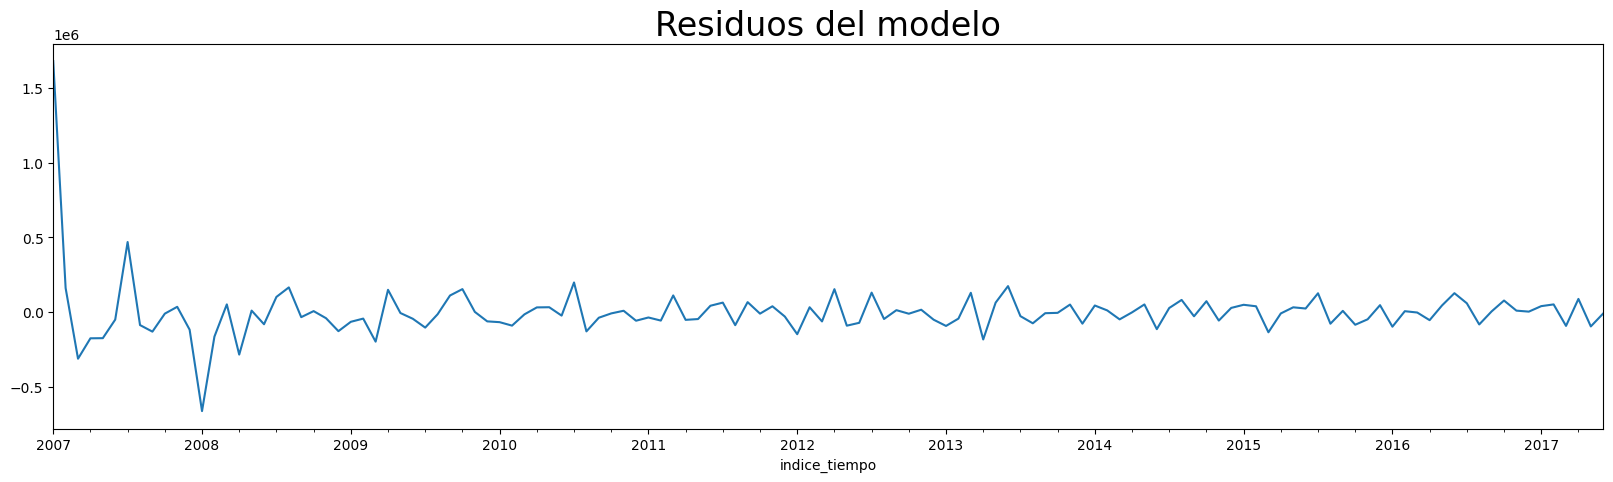

In [ ]:
modeloSARIMA2_fit.resid.plot(figsize=(20,5))
plt.title("Residuos del modelo",size=24)
plt.show()

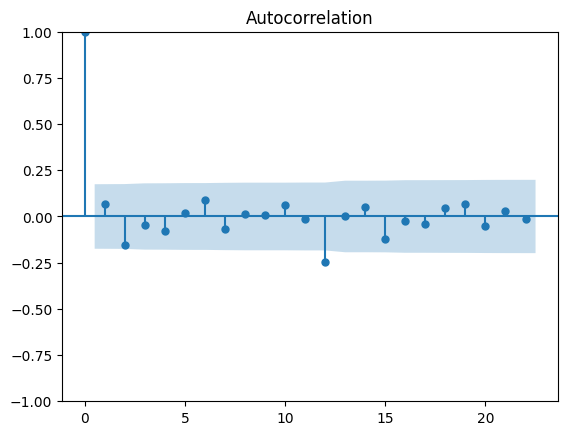

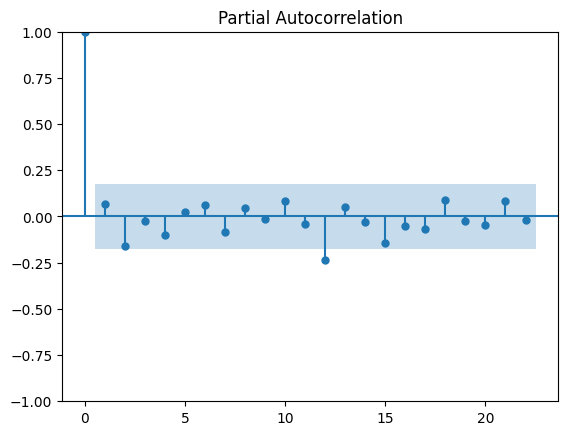

In [ ]:
plot_acf(modeloSARIMA2_fit.resid);
plot_pacf(modeloSARIMA2_fit.resid);

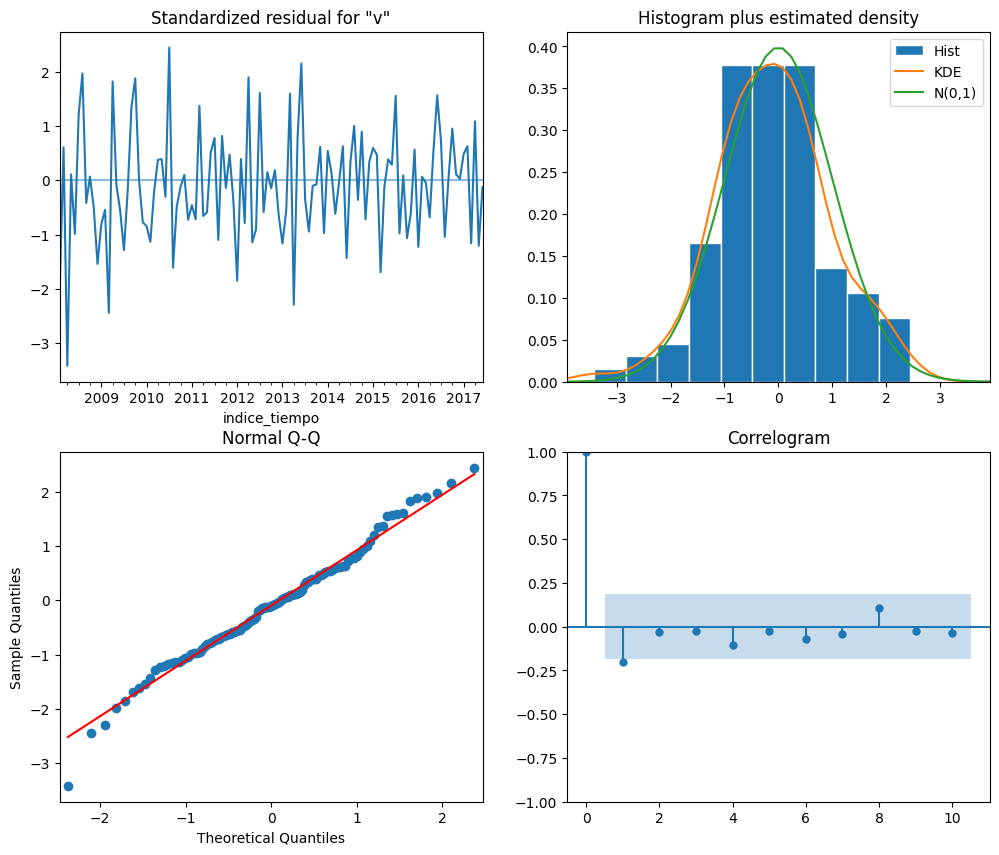

In [ ]:
# Diagnostico grafico los residuos del modelo
fig_res_2 = modeloSARIMA2_fit.plot_diagnostics(figsize=(12,10))

Text(0, 0.5, 'P-valores ')

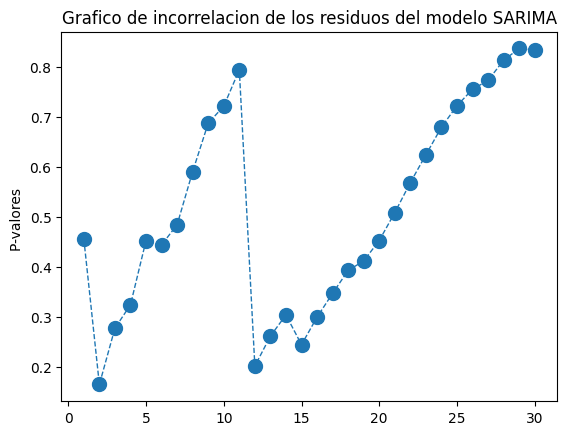

In [ ]:
Incorr_residuos_modelo_SARIMA2=sm.stats.acorr_ljungbox(modeloSARIMA2_fit.resid, lags=30)
plt.plot(Incorr_residuos_modelo_SARIMA2.lb_pvalue, marker='o', markersize=10, linestyle='--', linewidth=1)
plt.title("Grafico de incorrelacion de los residuos del modelo SARIMA")
plt.ylabel("P-valores ")

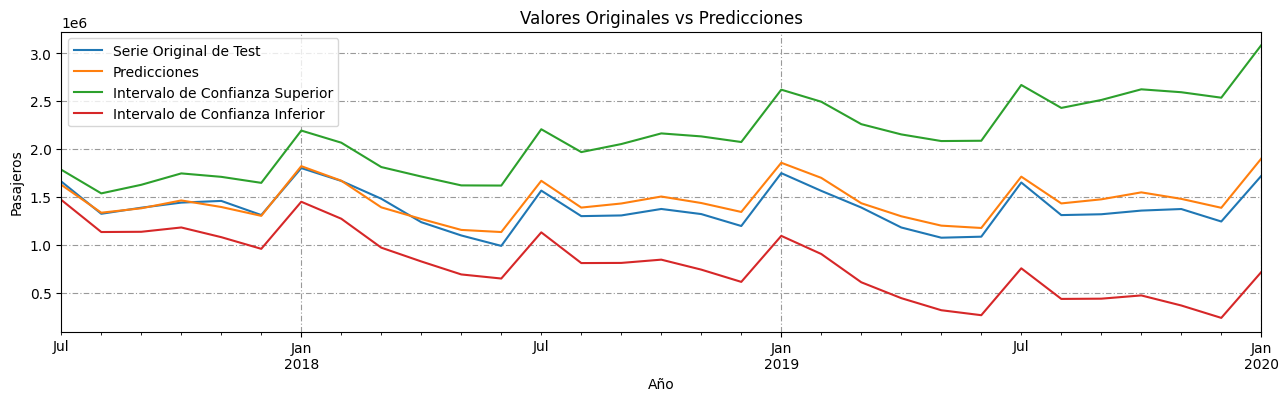

In [ ]:
# Utilizando el modelo realizamos la prediccion correspondiente al periodo de test
prediccionesSARIMA2 = modeloSARIMA2_fit.get_forecast(len(test))

# Graficamos la porcion de test de la serie original junto con las predicciones y los intervalos de confianza
graficar_pred(test, prediccionesSARIMA2.predicted_mean, prediccionesSARIMA2.conf_int())

In [ ]:
print ("Modelo SARIMA((0,1,2),(0,1,2)")
evaluar_metricas(test, prediccionesSARIMA2.predicted_mean)

Modelo SARIMA((0,1,2),(0,1,2)
MSE: 10942130567.615551
MAE: 89853.27515042327
RMSE: 104604.63932166465
MAPE: 0.0678


In [ ]:
modeloSARIMA = SARIMAX(train, order=(0,1,1), seasonal_order=(0,1,2,12))      # Mejor modelo segun autoarima = ARIMA(2,0,1)(2,1,0)[12]
modeloSARIMA_fit = modeloSARIMA.fit()
print(modeloSARIMA_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                viajeros   No. Observations:                  126
Model:             SARIMAX(0, 1, 1)x(0, 1, [1, 2], 12)   Log Likelihood               -1440.575
Date:                                 Thu, 19 Mar 2026   AIC                           2889.149
Time:                                         14:51:38   BIC                           2900.059
Sample:                                     01-01-2007   HQIC                          2893.576
                                          - 06-01-2017                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1697      0.054     -3.117      0.002      -0.276      -0

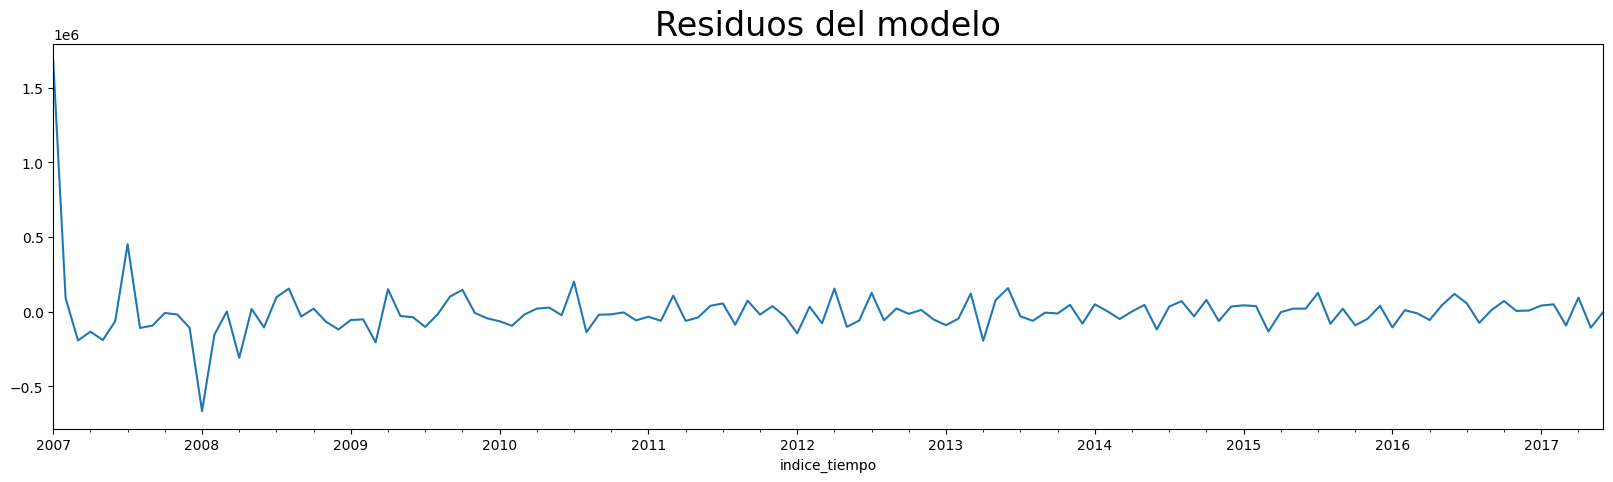

In [ ]:
modeloSARIMA_fit.resid.plot(figsize=(20,5))
plt.title("Residuos del modelo",size=24)
plt.show()

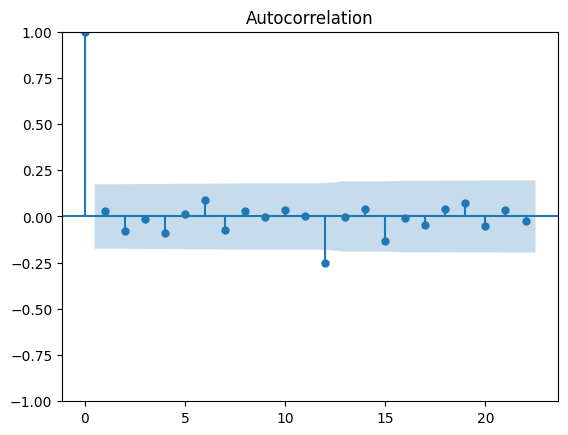

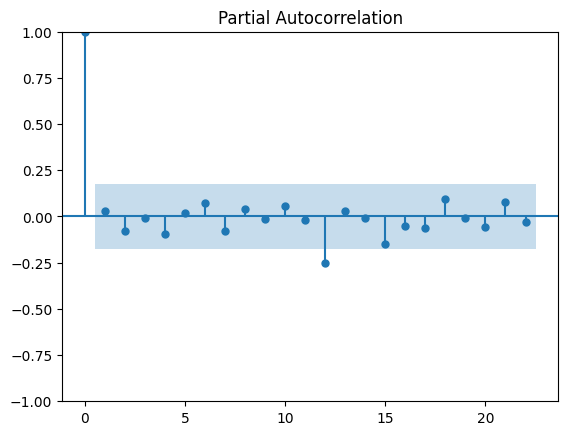

In [ ]:
plot_acf(modeloSARIMA_fit.resid);
plot_pacf(modeloSARIMA_fit.resid);

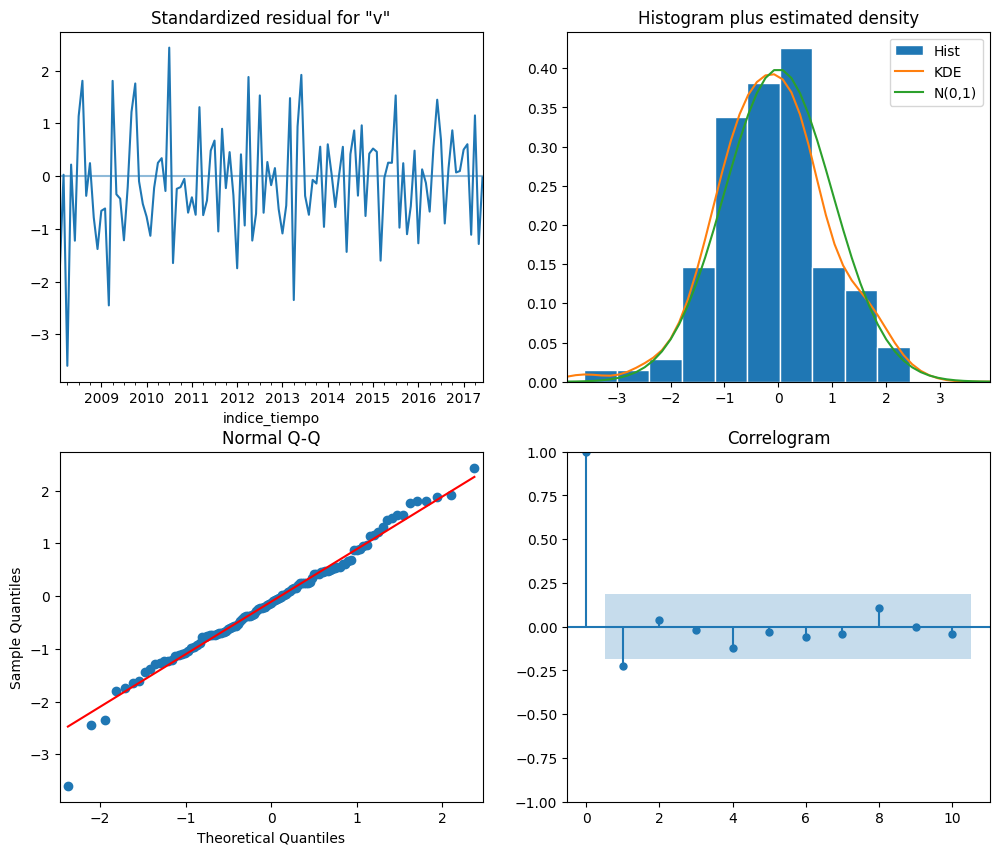

In [ ]:
# Diagnostico grafico los residuos del modelo
fig_res = modeloSARIMA_fit.plot_diagnostics(figsize=(12,10))

Text(0, 0.5, 'P-valores ')

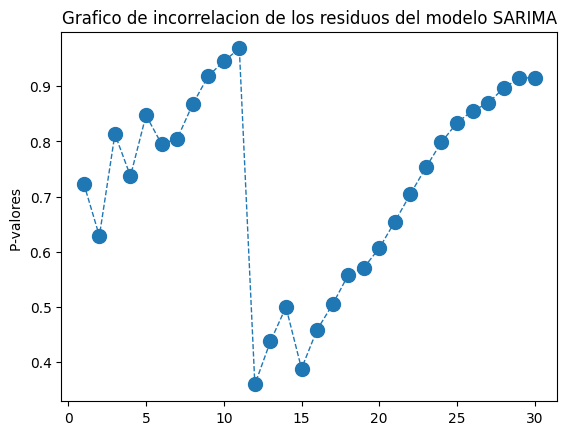

In [ ]:
Incorr_residuos_modelo_SARIMA2=sm.stats.acorr_ljungbox(modeloSARIMA_fit.resid, lags=30)
plt.plot(Incorr_residuos_modelo_SARIMA2.lb_pvalue, marker='o', markersize=10, linestyle='--', linewidth=1)
plt.title("Grafico de incorrelacion de los residuos del modelo SARIMA")
plt.ylabel("P-valores ")

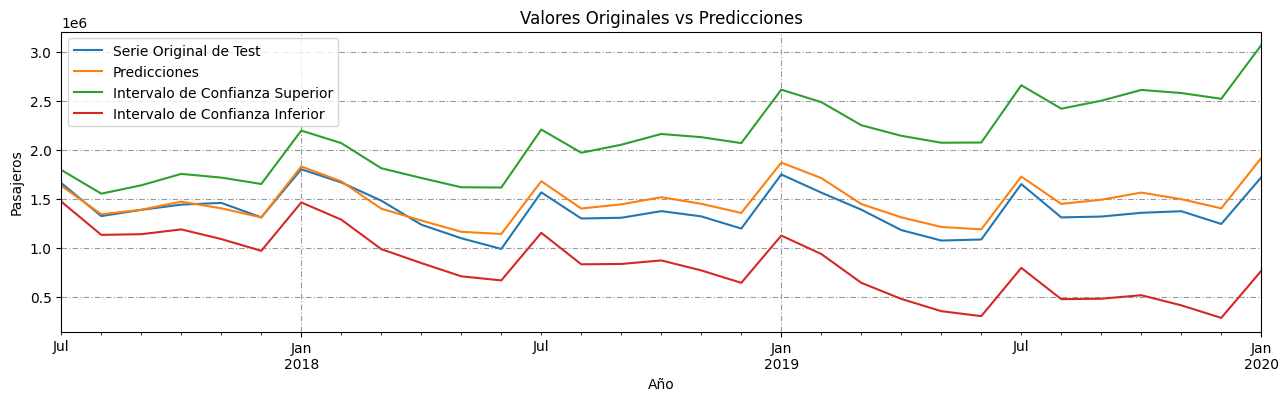

In [ ]:
# Utilizando el modelo realizamos la prediccion correspondiente al periodo de test
prediccionesSARIMA = modeloSARIMA_fit.get_forecast(len(test))

# Graficamos la porcion de test de la serie original junto con las predicciones y los intervalos de confianza
graficar_pred(test, prediccionesSARIMA.predicted_mean, prediccionesSARIMA.conf_int())

In [ ]:
print ("Modelo SARIMA((0,1,1),(0,1,2)")
evaluar_metricas(test, prediccionesSARIMA.predicted_mean)

Modelo SARIMA((0,1,1),(0,1,2)
MSE: 13216068953.872435
MAE: 99046.64964139741
RMSE: 114961.16280671675
MAPE: 0.0747


# Ensemble Manual de ambos modelos SARIMA

In [ ]:
ensemble_pred = (prediccionesSARIMA.predicted_mean + prediccionesSARIMA2.predicted_mean) / 2

Intervalos de confianza

In [ ]:
# Obtener el intervalo de confianza modelo SARIMA 3
intervalo_confianza2 = prediccionesSARIMA2.conf_int()

# Seleccionar únicamente la columna "lower viajeros"
lower_viajeros2 = intervalo_confianza2['lower viajeros']

In [ ]:
# Obtener el intervalo de confianza modelo SARIMA 2
intervalo_confianza = prediccionesSARIMA.conf_int()

# Seleccionar únicamente la columna "lower viajeros"
lower_viajeros = intervalo_confianza['lower viajeros']

In [ ]:
# Obtener el intervalo de confianza modelo SARIMA 3
intervalo_confianza2 = prediccionesSARIMA2.conf_int()

# Seleccionar únicamente la columna "upper viajeros"
upper_viajeros2 = intervalo_confianza2['upper viajeros']

In [ ]:
# Obtener el intervalo de confianza modelo SARIMA 2
intervalo_confianza = prediccionesSARIMA.conf_int()

# Seleccionar únicamente la columna "upper viajeros"
upper_viajeros = intervalo_confianza['upper viajeros']

In [ ]:
# Promedio de las predicciones de ambos modelos
upper_viajeros_ensemble = (upper_viajeros + upper_viajeros2) / 2

In [ ]:
# Promedio de las predicciones de ambos modelos
lower_viajeros_ensemble = (lower_viajeros + lower_viajeros2) / 2

In [ ]:
serie1 = pd.Series(lower_viajeros_ensemble, index=lower_viajeros_ensemble.index)
serie2 = pd.Series(upper_viajeros_ensemble, index=upper_viajeros_ensemble.index)

# Crear un DataFrame combinando las dos series
df = pd.DataFrame({'lower viajeros': serie1, 'upper viajeros': serie2})

# Mostrar el DataFrame resultante
print(df)

            lower viajeros  upper viajeros
2017-07-01    1.469809e+06    1.789081e+06
2017-08-01    1.132294e+06    1.544389e+06
2017-09-01    1.136987e+06    1.631918e+06
2017-10-01    1.183926e+06    1.749659e+06
2017-11-01    1.084053e+06    1.712649e+06
2017-12-01    9.630481e+05    1.648762e+06
2018-01-01    1.455894e+06    2.194317e+06
2018-02-01    1.279523e+06    2.067133e+06
2018-03-01    9.778009e+05    1.811701e+06
2018-04-01    8.347955e+05    1.712547e+06
2018-05-01    6.992448e+05    1.618758e+06
2018-06-01    6.570074e+05    1.616466e+06
2018-07-01    1.140859e+06    2.206619e+06
2018-08-01    8.199467e+05    1.968829e+06
2018-09-01    8.224483e+05    2.051631e+06
2018-10-01    8.576102e+05    2.162159e+06
2018-11-01    7.544139e+05    2.130205e+06
2018-12-01    6.271486e+05    2.070670e+06
2019-01-01    1.108550e+06    2.616762e+06
2019-02-01    9.198625e+05    2.490103e+06
2019-03-01    6.252290e+05    2.255138e+06
2019-04-01    4.601958e+05    2.147665e+06
2019-05-01 

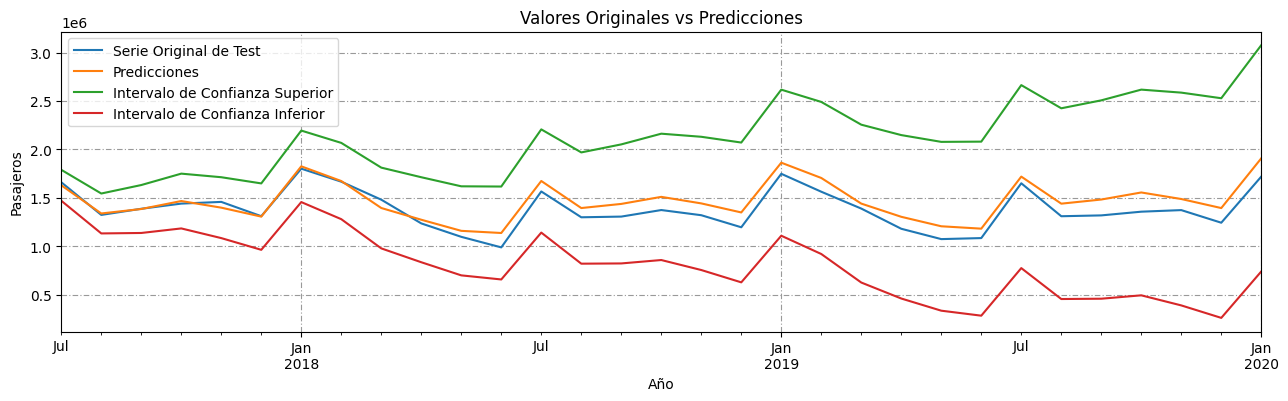

In [ ]:
# Graficamos la porcion de test de la serie original junto con las predicciones y los intervalos de confianza
graficar_pred(test, ensemble_pred, df)

In [ ]:
print("Metrica de el ensemble")
evaluar_metricas(test, ensemble_pred)

Metrica de el ensemble
MSE: 12043021932.932005
MAE: 94413.43407068207
RMSE: 109740.70317312535
MAPE: 0.0712


In [ ]:
print ("Modelo Primer SARIMA corrido((0,1,2),(0,1,2) ")
evaluar_metricas(test, prediccionesSARIMA2.predicted_mean)

Modelo Primer SARIMA corrido((0,1,2),(0,1,2) 
MSE: 10942130567.615551
MAE: 89853.27515042327
RMSE: 104604.63932166465
MAPE: 0.0678


In [ ]:
print ("Modelo Segundo SARIMA Corrido((0,1,1),(0,1,2)")
evaluar_metricas(test, prediccionesSARIMA.predicted_mean)

Modelo Segundo SARIMA Corrido((0,1,1),(0,1,2)
MSE: 13216068953.872435
MAE: 99046.64964139741
RMSE: 114961.16280671675
MAPE: 0.0747


Recordamos que:
Las metricas dicen que=

- MSE (Mean Squared Error)= penaliza fuertemente los errores grandes. Menor es mejor.
-MAE (Mean Absolute Error)= error absoluto promedio. Menor es mejor.
-RMSE (Root MSE): similar al MSE pero en las mismas unidades que la variable. Menor es mejor.
-MAPE (Mean Absolute Percentage Error)= error relativo promedio. Menor es mejor.

Mejor modelo:
SARIMA((0,1,2),(0,1,2))
Segundo ensambles
Tercero (0,1,1),(0,1,2))  -- > La significancia de los coeficientes evalua si podemos afirmar con confianza que ese parametro es distinto de cero en la muestra

Fin del codigo - Gracias